# M1.Ex2: Model Experience vs Salary

- Run: [**Open In Colab**](https://colab.research.google.com/github/HassanAlgoz/B5/blob/main/content/W3/M1/exercises/ex2_reg.ipynb)
- Raw Dataset: [Salary Data.csv](https://raw.githubusercontent.com/HassanAlgoz/B5/main/content/datasets/Salary%20Data.csv)

In [5]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

### Step 1. Load the data

In [6]:
df = pd.read_csv(r"C:\Users\Renad\Downloads\Salary Data.csv")

### Step 2.a Assign variables `X` to the features and `y` to the target

In [7]:
X = df[['Experience Years']] 
y = df['Salary']    

### Step 2.b print the type of each

In [8]:
print(f"X type: {type(X)}, y type: {type(y)}")

X type: <class 'pandas.DataFrame'>, y type: <class 'pandas.Series'>


### Step 2.c identify whether the target is categorical or numerical & whether the task is regression or classification

In [ ]:
print(f"Target data type: {y.dtype}")
if pd.api.types.is_numeric_dtype(y):
    print("Target is Numerical -> Regression Task")
else:
    print("Target is Categorical -> Classification Task")

Target data type: int64
Target is Numerical -> Regression Task


### Step 3. Identify the number of samples and columns of both the data matrix and the target

In [12]:
print(f"Samples/Columns in X: {X.shape}")
print(f"Samples in y: {y.shape}")

Samples/Columns in X: (40, 1)
Samples in y: (40,)


### Step 4. Summarize the distribution of the data (min, max, median, mean, and standard deviation)

In [11]:
df.describe()

,Experience Years,Salary
count,40.000000,40.000000
mean,5.152500,74743.625000
std,2.663715,25947.122885
min,1.100000,37731.000000
25%,3.200000,56878.250000
50%,4.600000,64472.500000
75%,6.875000,95023.250000
max,10.500000,122391.000000


### Step 5. Plot the feature vs the target

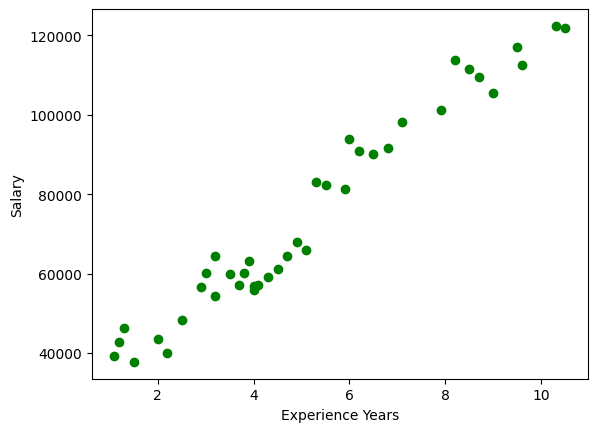

In [13]:
plt.scatter(X, y, color='green')
plt.xlabel('Experience Years')
plt.ylabel('Salary')
plt.show()

### Step 6. What is the relationship between the feature and the target? (increasing or decreasing or none)

In [14]:
correlation = df['Experience Years'].corr(df['Salary'])
print(f"Correlation: {correlation:.4f}")

if correlation > 0:
    print("The relationship is Increasing (Positive)")

Correlation: 0.9777
The relationship is Increasing (Positive)


### Step 7. Initialize a regression model

In [15]:
model = LinearRegression()

### Step 8. Split the dataset into train and test sets

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Step 9.a Train the model on the training set

In [17]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Step 9.b Identify the learned slope and the y-intercept of the linear regression model

In [18]:
slope = model.coef_[0]
intercept = model.intercept_

print(f"Slope (m): {slope:.2f}")
print(f"Intercept (b): {intercept:.2f}")

Slope (m): 9408.03
Intercept (b): 26716.25


### Step 9.c how much salary does a person get with 2 years of experience?

In [ ]:
salary_2_years = model.predict([[2]])[0]
print(f"Salary for 2 years: {salary_2_years:.2f}")

### Step 9.d how much does an increase of 6 months of experience adds to a person's salary?

In [ ]:
increase_6_months = slope * 0.5
print(f"6 months increase adds: {increase_6_months:.2f} to the salary")

### Step 9.e if one has zero experience, then how much is the estimated salary?

In [19]:
zero_experience_salary = model.intercept_
print(f"The estimated salary for zero experience is: {zero_experience_salary:.2f}")

The estimated salary for zero experience is: 26716.25


### Step 10. Evaluate the model on the test set

In [21]:
accuracy_score = model.score(X_test, y_test)
print(f"Model Accuracy (R^2 Score): {accuracy_score:.4f}")

Model Accuracy (R^2 Score): 0.9069


### Step 11. Take a sample of three rows from the test set and make a prediction on them and check whether they match the true label or not

In [23]:
X_sample = X_test.head(3)
y_true = y_test.head(3)
y_pred = model.predict(X_sample)

comparison = pd.DataFrame({
    'Years of Experience': X_sample.values.flatten(),
    'Actual Salary': y_true.values,
    'Predicted Salary': y_pred
})

print(comparison)

   Years of Experience  Actual Salary  Predicted Salary
0                  4.5          61111      69052.390902
1                  4.0          56957      64348.375266
2                  4.0          55794      64348.375266


### Step 12. Plot the data and the regression line

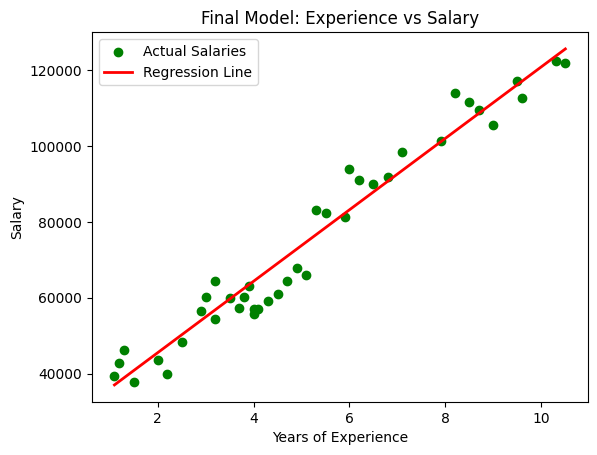

In [24]:
plt.scatter(X, y, color='green', label='Actual Salaries')
plt.plot(X, model.predict(X), color='red', linewidth=2, label='Regression Line')
plt.xlabel('Years of Experience')
plt.ylabel('Salary')
plt.title('Final Model: Experience vs Salary')
plt.legend() 
plt.show()